In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df=pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")

In [ ]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.shape

(614, 13)

In [ ]:
df['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [44]:
for col in df.columns:
  if df[col].dtype=='object':
    df[col].fillna(df[col].mode()[0],inplace=True)
  else:
    df[col].fillna(df[col].median(),inplace=True)


/tmp/ipykernel_975/2135117697.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)
/tmp/ipykernel_975/2135117697.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.drop('Loan_ID', axis=1, inplace=True)

In [46]:
x=df.drop('Loan_Status',axis=1)

In [47]:
y=df['Loan_Status']

In [7]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [48]:
cat_cols = x.select_dtypes(include='object').columns

In [49]:
x = pd.get_dummies(x, columns=cat_cols, drop_first=True)

In [50]:
x.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [51]:
x.head(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False


In [12]:
x.dtypes

,0
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Gender_Male,bool
Married_Yes,bool
Dependents_1,bool
Dependents_2,bool
Dependents_3+,bool


In [52]:
from sklearn.preprocessing import LabelEncoder


In [53]:
model=LabelEncoder()

In [54]:
y=model.fit_transform(df['Loan_Status'])

--you should assign the encoding into y then only it will be change.if you write  model.fit_transform(df['Loan_Status'])..it wont change in y.you still get y as n/y only.so write y=model.fit_transform(df['Loan_Status']).

In [16]:
y

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,

In [55]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = lr.predict(x_test_scaled)
y_prob = lr.predict_proba(x_test_scaled)[:, 1]

In [21]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[18, 25],
       [ 1, 79]])

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [23]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

np.float64(0.7494186046511628)

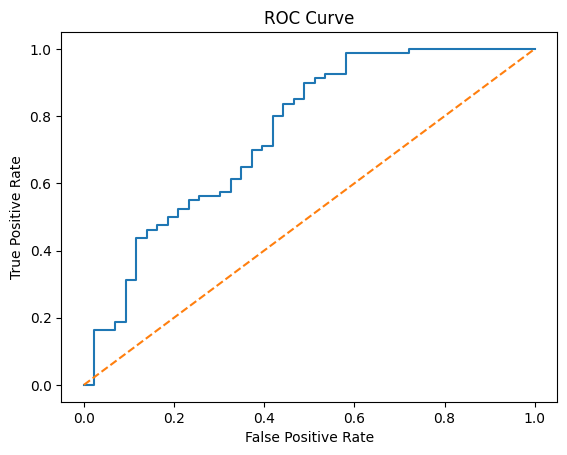

In [24]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
x

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,False,False,False,False,False,False,False,False,False
610,4106,0.0,40.0,180.0,1.0,True,True,False,False,True,False,False,False,False
611,8072,240.0,253.0,360.0,1.0,True,True,True,False,False,False,False,False,True
612,7583,0.0,187.0,360.0,1.0,True,True,False,True,False,False,False,False,True


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

In [62]:
x_train, _test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
x

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,False,False,False,False,False,False,False,False,False
610,4106,0.0,40.0,180.0,1.0,True,True,False,False,True,False,False,False,False
611,8072,240.0,253.0,360.0,1.0,True,True,True,False,False,False,False,False,True
612,7583,0.0,187.0,360.0,1.0,True,True,False,True,False,False,False,False,True


In [63]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [64]:
y_pred = rf.predict(x_test)

In [60]:
y_prob = rf.predict_proba(x_test)[:, 1]

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



in random forest also recall not get improved.if minority recall is poor data is imbalance.Thus handle it by using class weight or smote.

RANDOM FOREST


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

In [ ]:
pd.Series(y_train).value_counts()

,count
1,342
0,149


now data is balanced(after smote)

In [ ]:
df.shape

(614, 12)

In [ ]:
pd.Series(y_train_sm).value_counts()

,count
0,342
1,342


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [ ]:
rf.fit(x_train_sm, y_train_sm)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, recall_score, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(recall_score(y_test, y_pred))

[[18 25]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123

0.975


used class weight method to improvee recall

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)



In [ ]:
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(recall_score(y_test, y_pred))

[[18 25]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123

0.975


but recall not get improved in this method too

In [ ]:
import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=x_train.columns)
print(feat_imp.sort_values(ascending=False))

Credit_History             0.394486
LoanAmount                 0.125842
ApplicantIncome            0.123561
CoapplicantIncome          0.094589
Loan_Amount_Term           0.061890
Property_Area_Semiurban    0.052287
Married_Yes                0.032873
Dependents_1               0.019993
Education_Not Graduate     0.018178
Dependents_2               0.016259
Property_Area_Urban        0.016066
Self_Employed_Yes          0.015664
Gender_Male                0.014976
Dependents_3+              0.013334
dtype: float64


after using smote recall not improved.Then used class weight,here also recall not increased for class 0.

In [ ]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Class ratio:", ratio)

Class ratio: 0.43567251461988304


In [69]:
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)

model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
y_pred = model.predict(x_test)

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

[[22 21]
 [12 68]]
              precision    recall  f1-score   support

           0       0.65      0.51      0.57        43
           1       0.76      0.85      0.80        80

    accuracy                           0.73       123
   macro avg       0.71      0.68      0.69       123
weighted avg       0.72      0.73      0.72       123

Recall: 0.85
